<a href="https://colab.research.google.com/github/WPozz/Calories-and-Wellbeing/blob/main/Gruppo11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progettino

In [ ]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import string
import re
import math

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE

from google.colab import files
from google.colab import drive

print('Libraries succesfully imported')


Libraries succesfully imported


In [ ]:
# Data loading:

# drive.mount('/content/gdrive')
# %cd '/content/gdrive/My Drive/DL'

try:
    raw_data = pd.read_csv('mtsamples.csv')
    print("Data succesfully loaded")
except FileNotFoundError:
    print(f"Error: data file not found.")

# Print basic info
print("Initial Data Info:")
print(raw_data.columns)
raw_data.head(5)

Data succesfully loaded
Initial Data Info:
Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


**Pre-pre-processing plot functions**

Here we define the functions with the plots for the EDA. The major plots are:
1. Label (class) distribution
2. Top k N-grams in the dataset
3. Top k N-grams for each label  

In [ ]:

# Barplot with label:

def plot_label_distribution(raw_data, column, title, filename):

    """
    Helper function to create and save a bar plot of a column's distribution.

    Inputs:
            raw_data = (list) data to analyze
            column   = (string) column to analyze
            title    = (string) title of the plot
            filename = (string)
    Output:
            none (just the plot)

    """
    print(f"Generating plot: {title}...")
    plt.figure(figsize=(10, 12))

    # Plotting
    sns.countplot(
        y=column,
        data=raw_data,
        order=raw_data[column].value_counts().index,
        palette='viridis'   # we can select another palette
    )

    # Formatting
    plt.title(title, fontsize=16)
    plt.xlabel('Number of Samples', fontsize=12)
    plt.ylabel('Medical Specialty', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show


# N-grams in the whole dataset:

def plot_top_ngrams(text_data,n,top_k,title):
    """
    This function creates and saves a bar plot
    for the top N-grams :

    Inputs:
            text_data = the actual data
            n = (scalar) number of grams to consider
            top_k = (scalar) how many elements to show
            title = (string) title of the plot
    Output:
            None (just the plot)

    """
    print(f"Generating plot: {title}...")


    # We remove the "stop words" and look for n-grams with (n x n) dimension

    vec = CountVectorizer(
         stop_words='english',
         ngram_range=(n, n)
     )


    X = vec.fit_transform(text_data)

    # We sum the counts for each n-gram across
    counts = X.sum(axis=0)

    # Get the names of the features, the n-grams and the counts
    words = vec.get_feature_names_out()

    # Create a df with n-grams and their counts
    counts_df = pd.DataFrame({
    'ngram': words,
    'count': np.asarray(counts).flatten() # Convert the row of the matrix into a dense array
     })

    # We only keep the top_k
    top_counts_df = counts_df.sort_values(by='count', ascending=False).head(top_k)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(
         x='count',
         y='ngram',
        data=top_counts_df,
        palette='viridis_r' # reversed palette
         )
    plt.title(title, fontsize=16)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('N-Gram', fontsize=12)
    plt.tight_layout()
    plt.show()


# Sentence lenght:

def plot_lenghts(text_data):
    """
    This function retrives and plots the average lenght of the sentences.

    Inputs:
            text_data = (list) data to analyze

    Outputs:
            None (just the plot)

    """
    sentence_lengths = [len(sentence.split()) for sentence in text_data]

    plt.figure(figsize=(10, 6))
    sns.histplot(sentence_lengths, bins='auto', kde=True, color='green', shrink= 1)
    plt.title('Distribution of Sentence Lengths')
    plt.xlabel('Sentence Length (words)')
    plt.ylabel('Frequency')
    plt.show()

    print(f"Average sentence length: {np.mean(sentence_lengths):.2f} words")
    print(f"Median sentence length: {np.median(sentence_lengths)} words")
    print(f"Max sentence length: {np.max(sentence_lengths)} words")
    print(f"Min sentence length: {np.min(sentence_lengths)} words")



# N-grams per class

def plot_ngrams_per_class(data, text_col, class_col, top_k=15, n=1, num_classes=6):
    """
    Plots a grid of bar charts showing the top N-grams for the
    top N most frequent classes.

    Inputs:
            data = (dataframe) data to analyze
            text_col = (string) name of the text column
            class_col = (string) name of the class column
            top_k =  (scalar) how many grams to show
            n = (scalar) number of grams to consider
            num_classes = (scalar) Number of classes to show

    Outputs:
            None (just the plots)
    """
    print(f"Generating plot: Top {n}-grams per Class (Top {num_classes})...")
    data_clean = data.dropna(subset=[text_col, class_col])
    top_classes = data_clean[class_col].value_counts().nlargest(num_classes).index

    ncols = 3
    nrows = math.ceil(num_classes / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 7))
    axes = axes.flatten() # Flatten the grid for easy iteration

    for i, specialty in enumerate(top_classes):
        ax = axes[i]
        specialty_text = data_clean[data_clean[class_col] == specialty][text_col]

        try:
            vec = CountVectorizer(stop_words='english', ngram_range=(n, n))
            X = vec.fit_transform(specialty_text)
            counts = X.sum(axis=0)      # Compiler gives error but works anyway
            words = vec.get_feature_names_out()

            counts_df = pd.DataFrame({'ngram': words, 'count': np.asarray(counts).flatten()})
            top_counts_df = counts_df.sort_values(by='count', ascending=False).head(top_k)

            sns.barplot(x='count', y='ngram', data=top_counts_df, ax=ax, palette='viridis_r', hue='ngram', legend=False)
            ax.set_title(f"Top {n}-grams for '{specialty}'", fontsize=14)
            ax.set_xlabel('Frequency')
            ax.set_ylabel(f'{n}-gram')
        except ValueError:
            # This can happen if a specialty has no text after stopword removal
            ax.set_title(f"Could not generate {n}-grams for '{specialty}'", fontsize=14)
            ax.text(0.5, 0.5, 'Not enough data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'top_{n}grams_per_class.png')
    print(f"Saved plot to top_{n}grams_per_class.png")
    plt.close()




# Let's do sentence lenght per label:
# Mi rendo conto che la function è brutta ma era la cosa più pratica da fare in 2 min.

def plot_lenghts_per_class(data, text_col, class_col, num_classes=6):
  """
    Plots sentence lenghts per class.

    Inputs:
            data = (dataframe) data to analyze
            text_col = (string) name of the text column
            class_col = (string) name of the class column
            num_classes = (scalar) Number of classes to show

    Outputs:
            None (just the plots)

  """
  print(f"Generating plot: Sentence Lenghts per Class (Top {num_classes})...")
  data_clean = data.dropna(subset=[text_col, class_col])
  top_classes = data_clean[class_col].value_counts().nlargest(num_classes).index
  ncols = 3
  nrows = math.ceil(num_classes / ncols)
  fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 7))
  axes = axes.flatten() # Flatten the grid for easy iteration
  for i, specialty in enumerate(top_classes):
    ax = axes[i]
    specialty_text = data_clean[data_clean[class_col] == specialty][text_col]
    sentence_lengths = [len(sentence.split()) for sentence in specialty_text]
    sns.histplot(sentence_lengths, bins='auto', kde=True, color='green', shrink= 1, ax=ax)
    ax.set_title(f"Sentence Lengths for '{specialty}'", fontsize=14)
    ax.set_xlabel('Sentence Length (words)')
    ax.set_ylabel('Frequency')


    all_classes  = data_clean[class_col].value_counts().nlargest(40).index
  # Let's print a list with the average length per class for every class:
  for specialty in all_classes:

    specialty_text = data_clean[data_clean[class_col] == specialty][text_col]
    sentence_lengths = [len(sentence.split()) for sentence in specialty_text]
    print(f"Average sentence length for '{specialty}': {np.mean(sentence_lengths):.2f} words")


    # Hide any unused subplots
  for j in range(i + 1, len(axes)):
    axes[j].axis('off')
  plt.tight_layout()
  plt.savefig(f'sentence_lenghts_per_class.png')
  print(f"Saved plot to sentence_lenghts_per_class.png")
  plt.show()
  plt.close()


# Other plots ideas:
# Wordclouds for each class






Generating plot: Medical Specialty Distribution...


/tmp/ipython-input-1312770034.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


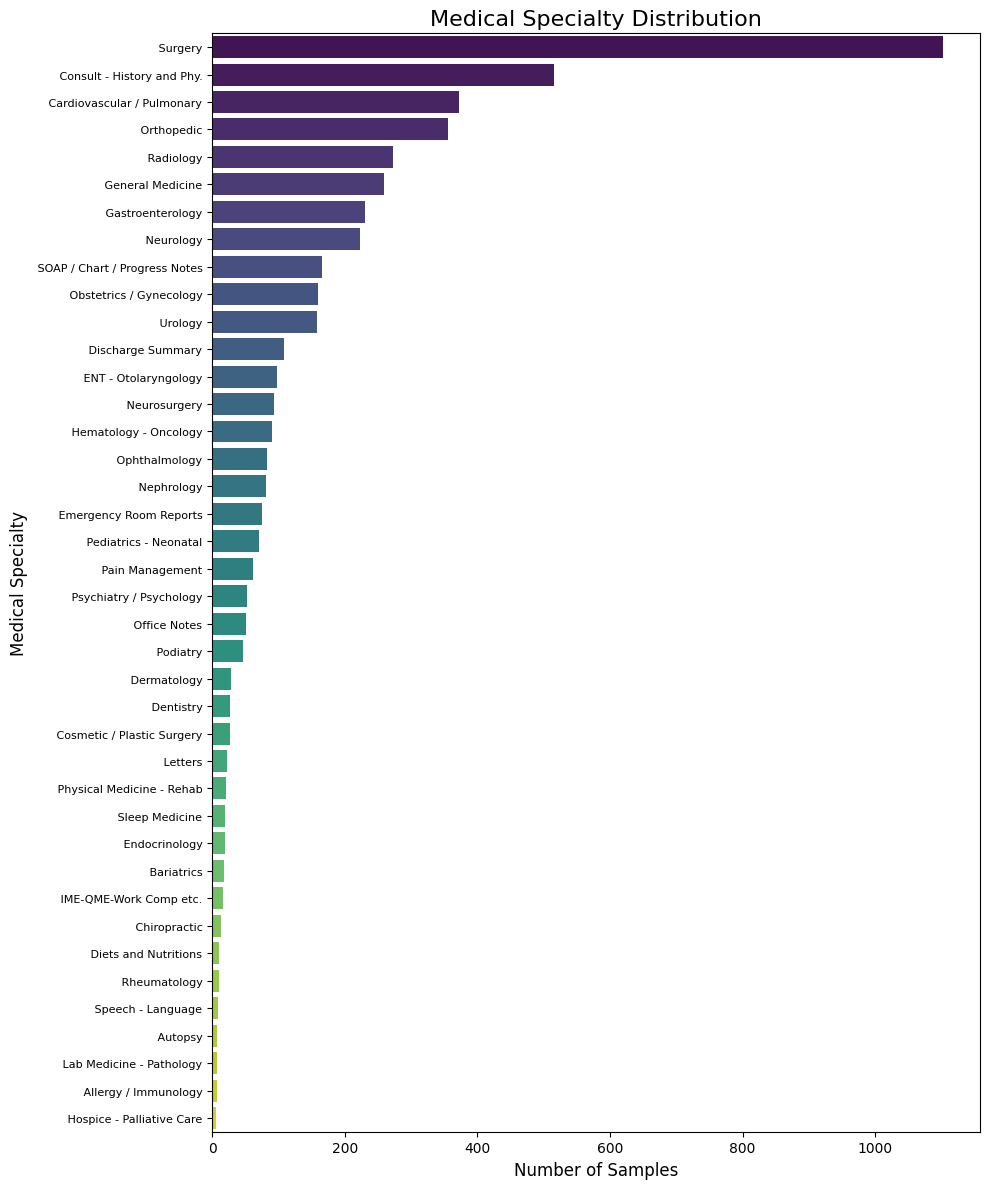

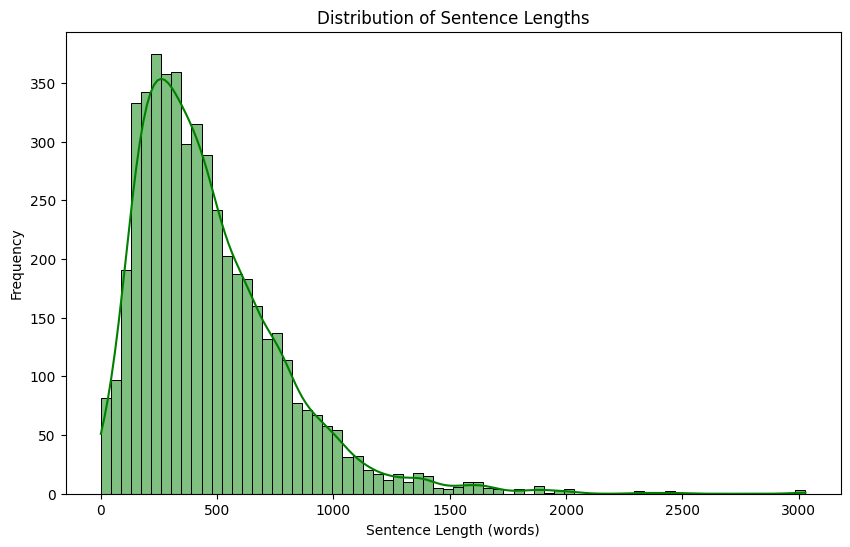

Average sentence length: 465.45 words
Median sentence length: 398.0 words
Max sentence length: 3029 words
Min sentence length: 1 words
Generating plot: Top 20 Most Frequently Occuring Unigrams...


/tmp/ipython-input-1312770034.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


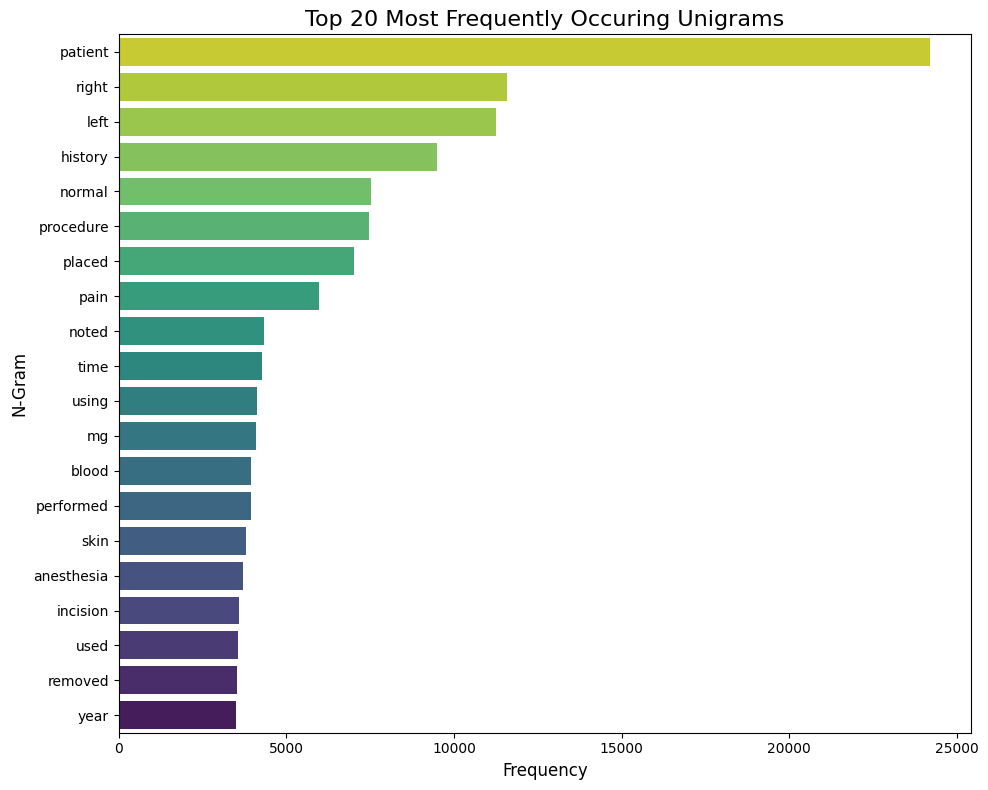

Generating plot: Top 20 Most Frequently Occuring Bigrams...


/tmp/ipython-input-1312770034.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


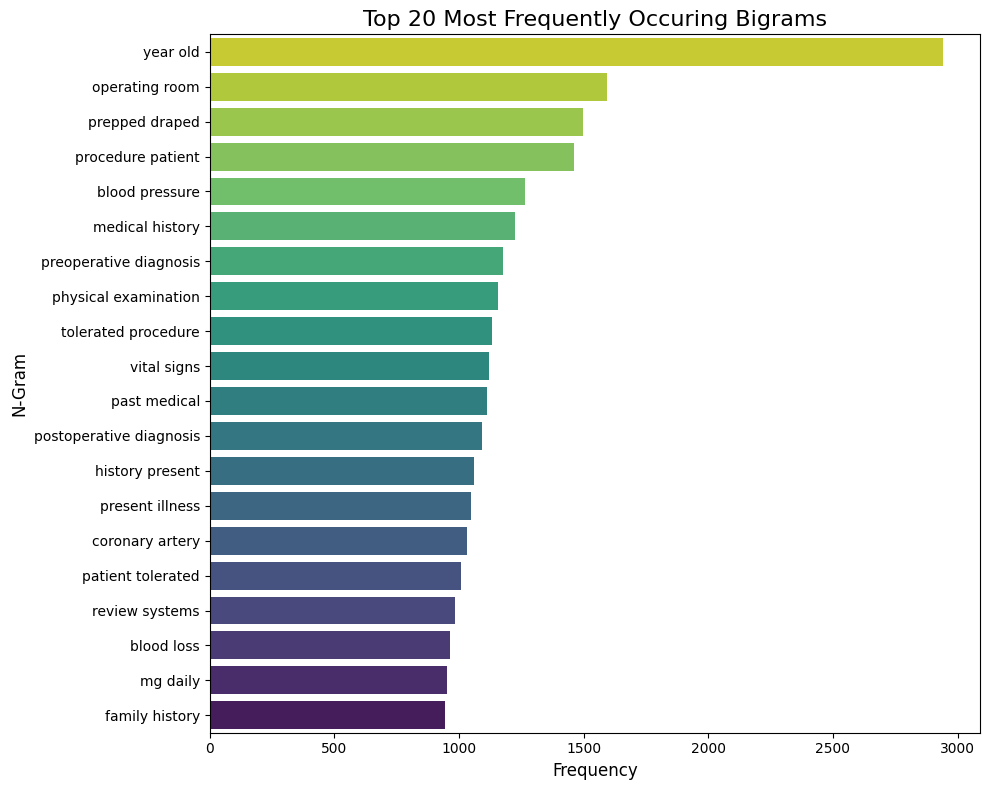

Generating plot: Top 20 Most Frequently Occuring Trigrams...


/tmp/ipython-input-1312770034.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


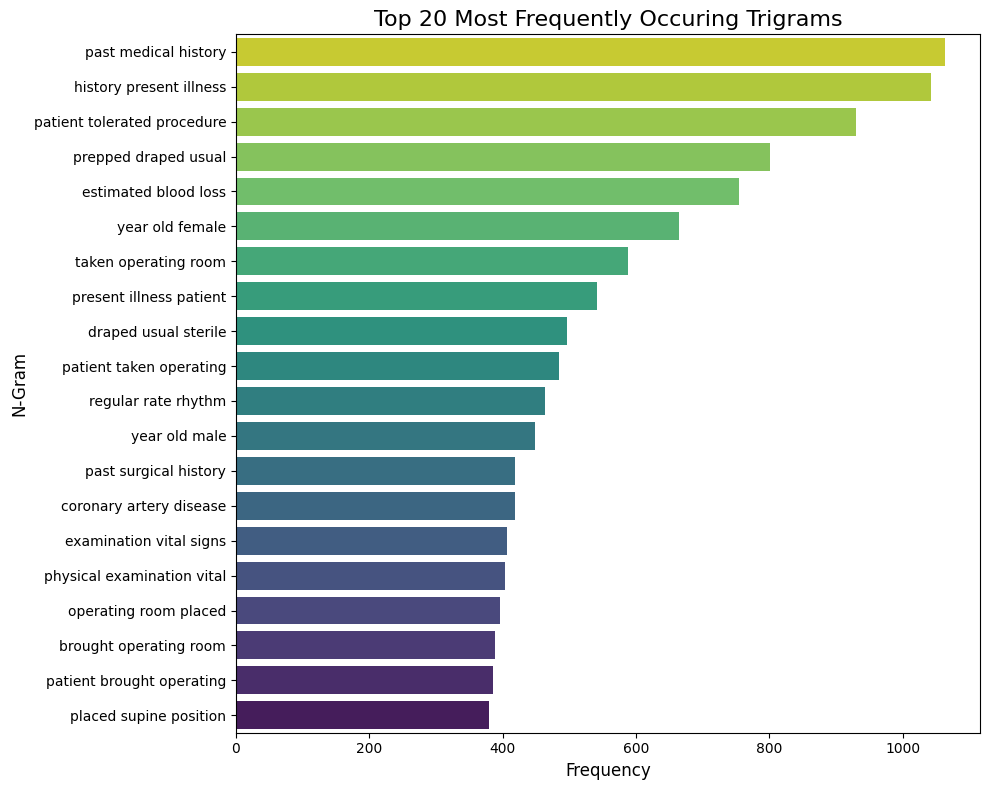

Generating plot: Top 1-grams per Class (Top 6)...
Saved plot to top_1grams_per_class.png
Generating plot: Top 2-grams per Class (Top 6)...
Saved plot to top_2grams_per_class.png
Generating plot: Top 3-grams per Class (Top 6)...
Saved plot to top_3grams_per_class.png
Generating plot: Sentence Lenghts per Class (Top 6)...
Average sentence length for ' Surgery': 484.15 words
Average sentence length for ' Consult - History and Phy.': 558.06 words
Average sentence length for ' Cardiovascular / Pulmonary': 433.60 words
Average sentence length for ' Orthopedic': 559.12 words
Average sentence length for ' Radiology': 274.61 words
Average sentence length for ' General Medicine': 467.10 words
Average sentence length for ' Gastroenterology': 358.69 words
Average sentence length for ' Neurology': 496.31 words
Average sentence length for ' SOAP / Chart / Progress Notes': 358.78 words
Average sentence length for ' Urology': 406.53 words
Average sentence length for ' Obstetrics / Gynecology': 468.32 

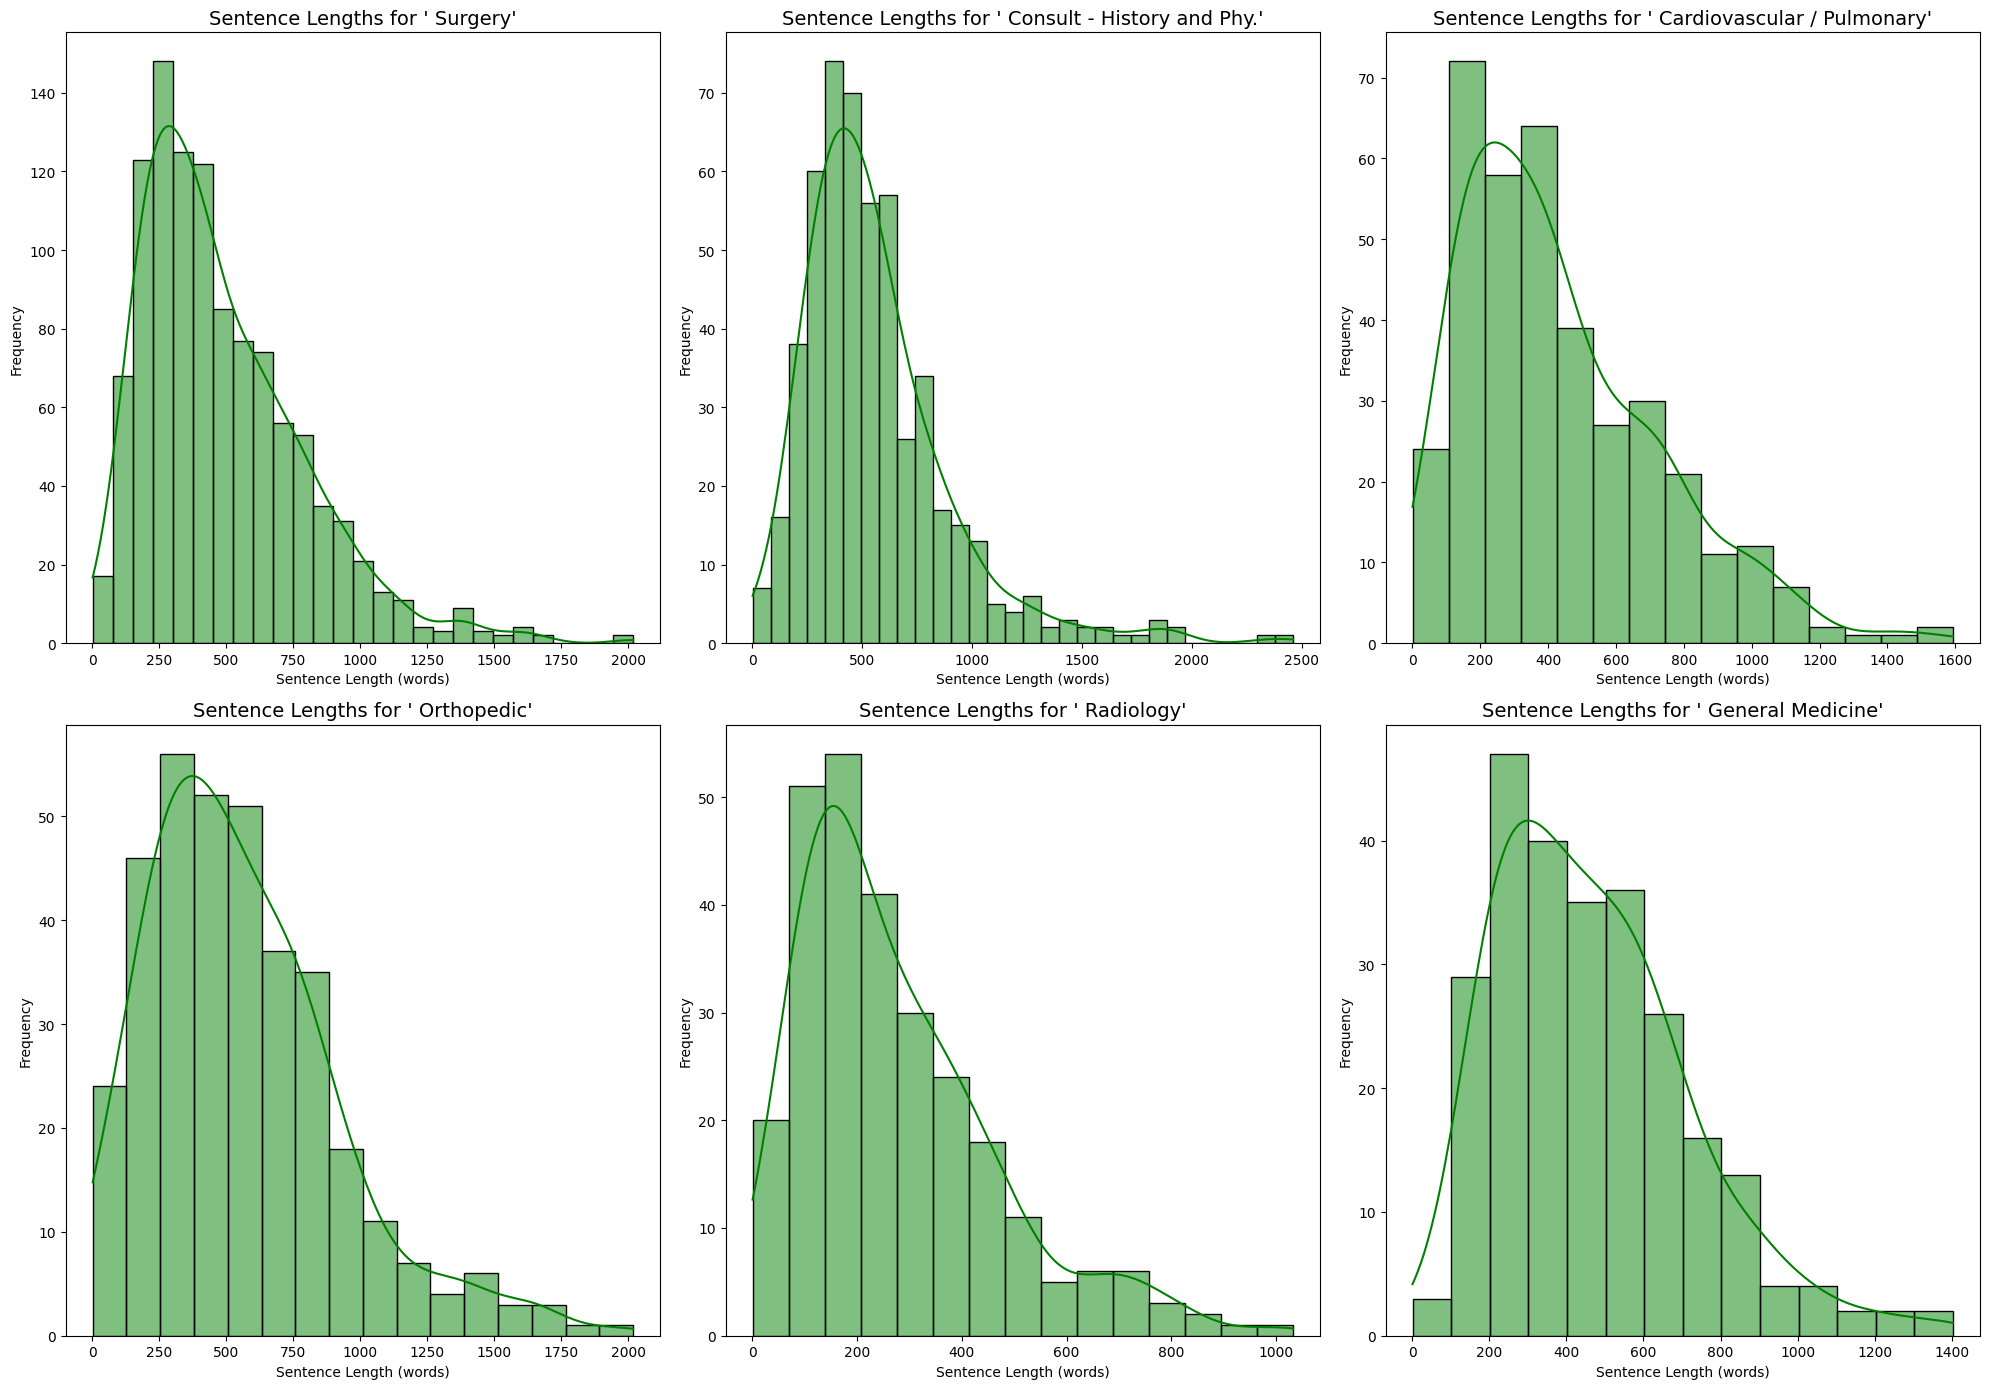

In [ ]:


try:

    plot_label_distribution(raw_data, 'medical_specialty', 'Medical Specialty Distribution', 'medical_specialty_distribution.png')

    text_data = raw_data.dropna(subset=['transcription'])['transcription'] # Remove Nan to avoid errors

    plot_lenghts(text_data)

    # N-grams general

    # Plot for N = 1
    plot_top_ngrams(text_data,n=1,top_k=20,title='Top 20 Most Frequently Occuring Unigrams')

    # Plot for N = 2
    plot_top_ngrams(text_data,n=2,top_k=20,title='Top 20 Most Frequently Occuring Bigrams')

    # Plot for N = 3
    plot_top_ngrams(text_data,n=3,top_k=20,title='Top 20 Most Frequently Occuring Trigrams')

    # N-grams per class:

    # Plot for N = 1
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=1, num_classes=6)

    # Plot for N = 2
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=2, num_classes=6)

    # Plot for N = 3
    plot_ngrams_per_class(raw_data, 'transcription', 'medical_specialty', top_k=15, n=3, num_classes=6)

    # Lenght per class:

    plot_lenghts_per_class(raw_data, 'transcription', 'medical_specialty', num_classes=6)
except KeyError:
    print('"transcription" column not found.')
except Exception as e:
    print(f"An error occurred: {e}")



**Pre-processing**

Looking at the initial plots, we see that the dataset has **two major problems**:
1. There are some very small but meaningfull classes (Allergy / Immunology - Hospice) with less than 20 samples.
2. There are some noisy and vague noisy classes (Consult - History and Phy SOAP / Chart).

This is a classic "**garbage in - garbage out**" problem where there is the risk of feeding the model with noisy and unbalanced data. This can result in low interpretability and poor performances.  

The idea is to pre-process the data by performing an aggressive **data cleaning** and **data augmentation**. The data cleaning function should:  

1. Drop NaNs and 'Unnamed: 0' column.
2. Merge similar classes ('Neurology' and 'Neurosurgery').
3. Remove a specific list of noisy/document-type labels (letters, office notes, ecc.).
4. Filter out any remaining classes with < min_samples.

The data augmentation will be performed using the "**back translation**" technique. We'll translate the samples in different languages (German, Italian and Russian) to augment the samples without altering the original meaning.

In [ ]:

def pre_processing_data(data, min_samples=50):
    """
    Performs aggressive cleaning of the 'medical_specialty' column
    based on the Model 3 strategy:
    1. Drops NaNs and 'Unnamed: 0' column.
    2. Merges similar classes
    3. Removes a specific list of noisy/document-type labels.
    4. Filters out any remaining classes with < min_samples.

    Inputs:
            "data" = (DataFrame) The raw data to clean.
            "min_samples" = (int) Threshold for the minimum samples per class.

    Output:
            (DataFrame) The pre-processed, cleaned and filtered data.
    """
    print("--- Starting Data Cleaning ---")
    print(f"Original dataset shape: {data.shape}")

    # Make a copy to avoid SettingWithCopyWarning
    data = data.copy()

    # 1. Initial cleanup
    if 'Unnamed: 0' in data.columns:
        data = data.drop(columns=['Unnamed: 0'])

    data['medical_specialty'] = data['medical_specialty'].str.strip()
    data = data.dropna(subset=['transcription', 'medical_specialty'])
    print(f"Shape after dropping NaNs: {data.shape}")

    # 2. Merge similar specialties (we should decide which one)
    merge_map = {
        'Bariatrics': 'Surgery',
        'Cosmetic / Plastic Surgery': 'Surgery',
        'Neurosurgery': 'Neurology / Neurosurgery',
        'Neurology': 'Neurology / Neurosurgery' # Map base class too
    }

    data['medical_specialty'] = data['medical_specialty'].replace(merge_map)
    print("Completed merging 'Bariatrics'/'Cosmetic' into 'Surgery' and 'Neurosurgery' into 'Neurology / Neurosurgery'.")

    # 3. Define and remove "noisy" labels (document types, not specialties)
    noisy_labels = [
        'Consult - History and Phy.',
        'SOAP / Chart / Progress Notes',
        'Discharge Summary',
        'Emergency Room Reports',
        'General Medicine',
        'Radiology',            # Debatable
        'Office Notes',
        'Letters',
        'IME-QME-Work Comp etc.',
        'Lab Medicine - Pathology',
        'Autopsy'               # Debatable
    ]


    noisy_count = data['medical_specialty'].isin(noisy_labels).sum()
    print(f"Found {noisy_count} samples with noisy labels to remove.")

    data = data[~data['medical_specialty'].isin(noisy_labels)]
    print(f"Shape after removing noisy labels: {data.shape}")

    # 4. Handle class imbalance by removing specialties with < min_samples
    specialty_counts = data['medical_specialty'].value_counts()
    specialties_to_keep = specialty_counts[specialty_counts >= min_samples].index

    original_classes = data['medical_specialty'].nunique()
    print(f"Classes before min_sample filter: {original_classes}")

    data = data[data['medical_specialty'].isin(specialties_to_keep)]
    print(f"Shape after removing classes with < {min_samples} samples: {data.shape}")

    final_classes = data['medical_specialty'].nunique()
    print(f"--- Cleaning Complete ---")
    print(f"Final number of classes: {final_classes}")

    return data.reset_index(drop=True)


In [ ]:

try:
     clean_data = pre_processing_data(raw_data, min_samples=50)
     print('Data pre-processing completed successfully.')
except KeyError:
    print('"transcription" or "medical_specialty" column not found.')
except Exception as e:
    print(f"An error occurred: {e}")

print("\n--- New Class Distribution (After Pre-processing) ---")
print(clean_data['medical_specialty'].value_counts())
print('Mean number of samples per class after cleaning:', clean_data['medical_specialty'].value_counts().mean())
print('Median number of samples per class after cleaning:', clean_data['medical_specialty'].value_counts().median())


--- Starting Data Cleaning ---
Original dataset shape: (4999, 6)
Shape after dropping NaNs: (4966, 5)
Completed merging 'Bariatrics'/'Cosmetic' into 'Surgery' and 'Neurosurgery' into 'Neurology / Neurosurgery'.
Found 1502 samples with noisy labels to remove.
Shape after removing noisy labels: (3464, 5)
Classes before min_sample filter: 26
Shape after removing classes with < 50 samples: (3245, 5)
--- Cleaning Complete ---
Final number of classes: 14
Data pre-processing completed successfully.

--- New Class Distribution (After Pre-processing) ---
medical_specialty
Surgery                       1133
Cardiovascular / Pulmonary     371
Orthopedic                     355
Neurology / Neurosurgery       317
Gastroenterology               224
Urology                        156
Obstetrics / Gynecology        155
ENT - Otolaryngology            96
Hematology - Oncology           90
Ophthalmology                   83
Nephrology                      81
Pediatrics - Neonatal           70
Pain Manag

# **Pre-Processing Results:**

The pre-processing left us with 14 classes (labels) to deal with. The dataset is still unbalanced but we managed to remove most of the noisiy labels along with classes with too few samples. Before performing the back translation we plot the results of the pre-procesing below.


Note (W): *We should split the data into test-validation-training before the second EDA as we're only interested in the training set (the others won't be touched by the data augmentation). We can also perform data partitioning after the second EDA but this could result in some "peeking" of the data.*

Here we show the EDA after the pre-processing.

Generating plot: Medical Specialty Distribution...


/tmp/ipython-input-3301588043.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


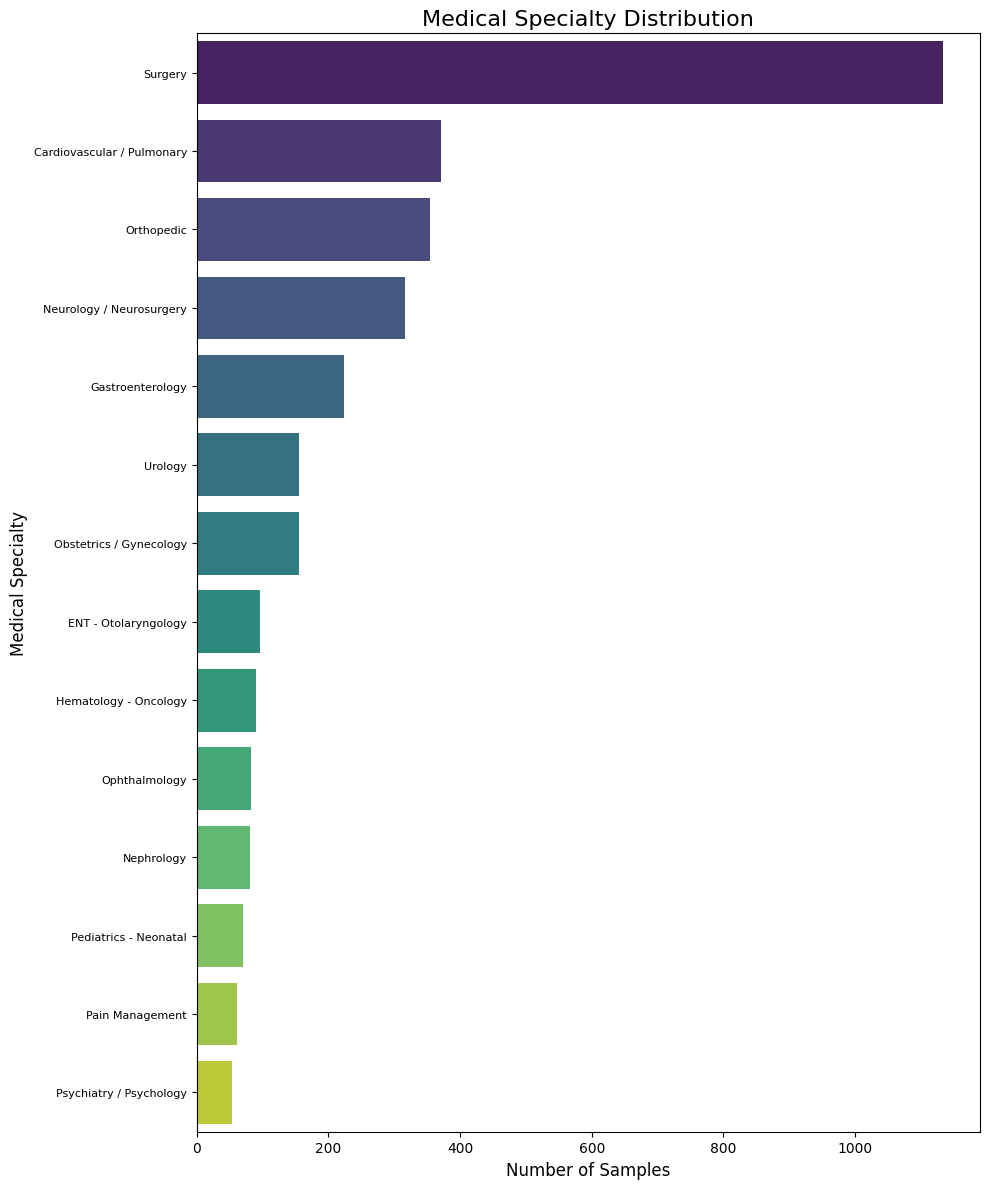

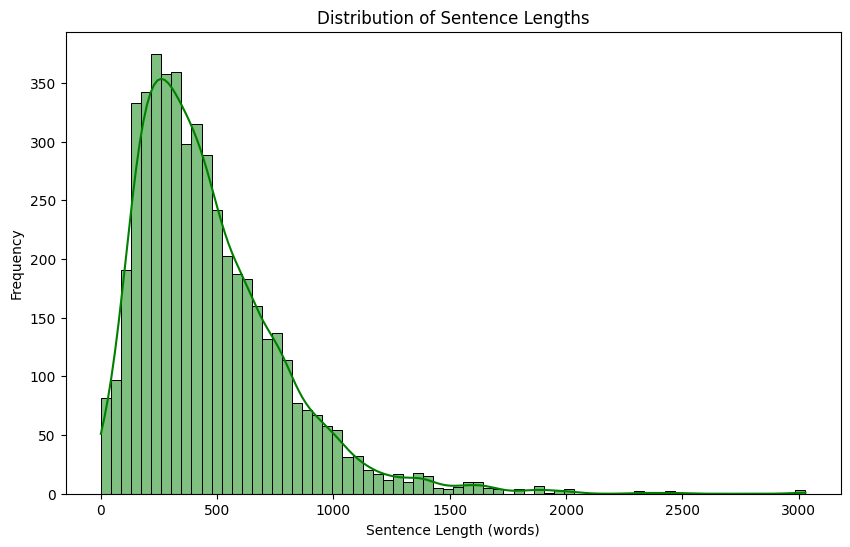

Average sentence length: 465.45 words
Median sentence length: 398.0 words
Max sentence length: 3029 words
Min sentence length: 1 words


In [ ]:
plot_label_distribution(clean_data, 'medical_specialty', 'Medical Specialty Distribution', 'medical_specialty_distribution.png')

text_data = raw_data.dropna(subset=['transcription'])['transcription'] # Remove Nan to avoid errors

plot_lenghts(text_data)

# **Data Partitioning:**

We split the data into three sets: Training, Validation and Test. We can change the proportion but i think that 65%-20%-15% can be a good start.

In [ ]:


def data_partition(data, label_col, train_size=0.65, val_size=0.15, test_size=0.20, random_state=15):
    """
    We split the data into Train, Validation and Test keeping the dataframe format.

    Inputs:
            data = (DataFrame) data to partition
            label_col = (string) name of the label column
            train_size = (float) proportion of the data to use for training
            val_size = (float) proportion of the data to use for validation
            test_size = (float) proportion of the data to use for testing
            random_state = (int) seed for reproducibility

    Outputs:
            train_df = (DataFrame) training set
            val_df = (DataFrame) validation set
            test_df = (DataFrame) testing set

    """
    print("--- Starting Data Partitioning ---")
    print("")

    # First split: Train vs (Validation + Test)

    train_df, temp_df = train_test_split(data,test_size=(val_size + test_size),stratify=data[label_col],random_state=random_state)

    # Second split: Validation vs Test

    relative_test_size = test_size / (val_size + test_size)

    val_df, test_df = train_test_split(temp_df,test_size=relative_test_size,stratify=temp_df[label_col],random_state=random_state)

    # Reset index to avoid further problmes
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"Train DF shape: {train_df.shape}")
    print(f"Val DF shape:   {val_df.shape}")
    print(f"Test DF shape:  {test_df.shape}")

    # We add a small barplot to show the proportions:
    # Create a summary dataframe for plotting
    split_counts_data = {'Split': ['Train', 'Validation', 'Test'],'Count': [len(train_df), len(val_df), len(test_df)]}
    split_counts_df = pd.DataFrame(split_counts_data)

    print("")

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Split', y='Count', data=split_counts_df, palette='muted', hue='Split', legend='auto')
    plt.title('Distribution of Data Across Splits', fontsize=16)
    plt.xlabel('Split', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.show()

    print("")
    print("--- Data Partitioning Complete ---")

    return train_df, val_df, test_df


--- Starting Data Partitioning ---

Train DF shape: (2109, 5)
Val DF shape:   (486, 5)
Test DF shape:  (650, 5)



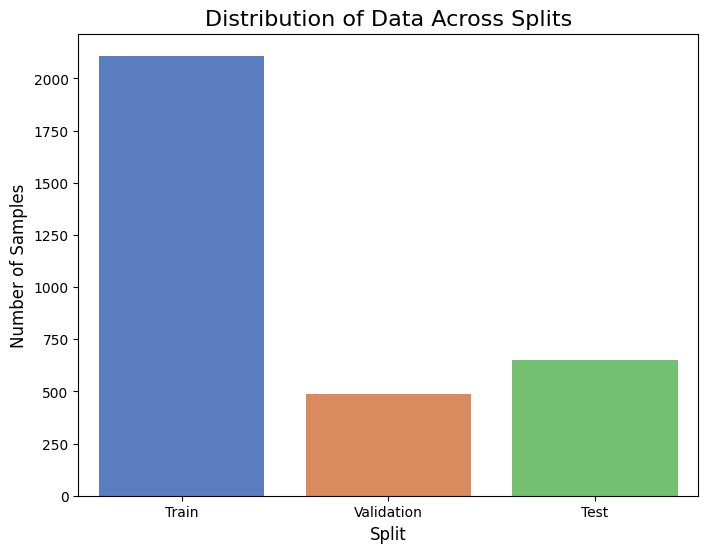


--- Data Partitioning Complete ---


In [ ]:
train_df, val_df, test_df = data_partition(clean_data, 'medical_specialty')

# **Back Translation:**

Here we define the function for the back translation. Important: To avoid **data leakage** the test/train split must be performed before the back translation. We should augment only the training set.

Back Tranlation aletrnatives:

- Random Swap: Randomly choose two words in the sentence and swap their positions. Do this n times. (fast n easy)

- Random Insertion: Find a random synonym of a random word in the sentence that is not a stop word. Insert that synonym into a random position in the sentence. Do this n times. (fast n easy)

- Shuffle Sentences Transform: In this transformation, if the given text sample contains multiple sentences these sentences are shuffled to create a new sample. (Albumentation library)



In [ ]:

# Work in progress

def data_agumentation(df, text_col, label_col, target_samples=300):
    """

    We apply Back Translation only to the minority classe in the dataframe.

    Inputs:
            df (dataframe) = Input dataframe
            text_col (string) = Name of the text column
            label_col (string) = Name of the label column
            target_samples (int) = Target number of samples for each class

    Output:
            final_df (dataframe) = Augmented dataframe

    """

    print("\n--- Starting Data Augmentation on DataFrame ---")

    # We use the gpu to speed things up:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}, Warining: CPU is very slow!")

    # Define first translation model: (En -> De -> En)
    back_translation_aug = naw.BackTranslationAug(
        from_model_name='',             # Idk yet which model to use :)
        to_model_name='',
        device=device
    )

    # Count labels:
    class_counts = df[label_col].value_counts()

    new_rows = [] # List to save new generated data

    for label, count in class_counts.items():
        if count < target_samples:
            n_needed = target_samples - count

            # We filter the dataframe:
            # For faster iteration we convert into lists:

            samples = df[df[label_col] == label][text_col].tolist()

            print(f"Class '{label}': generating {n_needed} samples...")

            generated = 0
            pbar = tqdm(total=n_needed)

            while generated < n_needed:
                for text in samples:
                    if generated >= n_needed:
                        break

                    # Here I also have some questions: I think we should try to avoid errors (and runtime)
                    # By cutting too short and too long text conversion (in this way we'll augment only short-medium phrases
                    # which is computationally better and we won't have errors with blank translations). I also think it's pointless to translate
                    # very small text (Heart attack -> Cardiac attack like ok thanks). In addition, if we use BERT models (the transformer) it has a
                    # 512 token limits (around 350 words) so it makes no sense to transalate more than that.

                    # 1. Skip very short texts (often noise or headers)
                    if len(text.split()) < 5:
                        continue

                    # 2. Truncate very long texts to save time/memory and BERT
                    if len(text.split()) > 350:
                        text = " ".join(text.split()[:350])

                    try:
                        aug_text = back_translation_aug.augment(text)
                        # Output nlpaug (stringa o lista)
                        if isinstance(aug_text, list):
                            aug_text = aug_text[0]

                        # Salva come dizionario (riga)
                        new_rows.append({text_col: aug_text, label_col: label})

                        generated += 1
                        pbar.update(1)
                    except Exception as e:
                        continue
            pbar.close()

    # We merge new data with the original dataframe (Should work)
    if len(new_rows) > 0:
        aug_df = pd.DataFrame(new_rows)
        # Concatenate and shuffle (randomness we like it)
        final_df = pd.concat([df, aug_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"Augmentation complete. Added {len(new_rows)} rows.")
        return final_df
    else:
        print("No augmentation needed.")
        return df.reset_index(drop=True)

### **Character Typo**

In [ ]:
# nlpaug.augmenter.char.KeyboardAug

# **Model selection:**

Here we'll select the model (or models) to train with. I think we can try 2 models, one "classic" model (RNNs or even simplier fully connected layers) that will perform very poorly (just like the logistic regression from the other guy). The other model will be a "state of the art" transformer based model (likely ClinicalBERT / BioBERT or somth like that). This second model will not only be theoretically correct (as transformers are designed for this task) but will also have way better performances.

